# Load Dataset

## Load NAB time series

In [1]:
## Imports
import pandas as pd
import numpy as np


In [2]:
import os

# Path to Numeta Anomoly Benchmark (NAB) data folder
base_path = "../data/NAB-master/data/realKnownCause/"

# Load one example file
file_path = os.path.join(base_path, "ambient_temperature_system_failure.csv")
df = pd.read_csv(file_path)

df.head()


,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


## Load Anomaly Labels (JSON)

In [3]:
import json  # to work with JSON files

# Tell Python where the labels file is
label_path = "../data/NAB-master/labels/combined_labels.json"

# Open the file and read its contents
with open(label_path, "r") as label_file:      # "r" = read mode, label_file = name for the opened file
    labels = json.load(label_file)             # turn the JSON into a Python dictionary called 'labels'

# 3. Shows the first 10 dataset keys names to confirm it loaded correctly
list(labels.keys())[:10]



['artificialNoAnomaly/art_daily_no_noise.csv',
 'artificialNoAnomaly/art_daily_perfect_square_wave.csv',
 'artificialNoAnomaly/art_daily_small_noise.csv',
 'artificialNoAnomaly/art_flatline.csv',
 'artificialNoAnomaly/art_noisy.csv',
 'artificialWithAnomaly/art_daily_flatmiddle.csv',
 'artificialWithAnomaly/art_daily_jumpsdown.csv',
 'artificialWithAnomaly/art_daily_jumpsup.csv',
 'artificialWithAnomaly/art_daily_nojump.csv',
 'artificialWithAnomaly/art_increase_spike_density.csv']

## Extract Labels for Selected Dataset

In [4]:
# Select the correct dataset key from the labels dictionary
dataset_key = "realKnownCause/ambient_temperature_system_failure.csv"

# Extract the list of anomaly timestamps for this dataset
label_times = labels[dataset_key]

# Display the timestamps
label_times


['2013-12-22 20:00:00', '2014-04-13 09:00:00']

## Add Labels to DataFrame

In [5]:
# Make sure the timestamp column is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Converting the label timestamps into datetime objects 
label_times_dt = pd.to_datetime(label_times)

# Create a new column: 1 if the timestamp is an anomaly, 0 otherwise
df["is_anomaly"] = df["timestamp"].isin(label_times_dt).astype(int)

# See the updated dataframe
df.head()


,timestamp,value,is_anomaly
0,2013-07-04 00:00:00,69.880835,0
1,2013-07-04 01:00:00,71.220227,0
2,2013-07-04 02:00:00,70.877805,0
3,2013-07-04 03:00:00,68.959400,0
4,2013-07-04 04:00:00,69.283551,0


# Explore Structure 

## Explore Dataset Structure

In [29]:
from IPython.display import display #formatting 
import matplotlib.pyplot as plt

In [30]:
# View first rows 
df.head()  

,timestamp,value,is_anomaly
0,2013-07-04 00:00:00,69.880835,0
1,2013-07-04 01:00:00,71.220227,0
2,2013-07-04 02:00:00,70.877805,0
3,2013-07-04 03:00:00,68.959400,0
4,2013-07-04 04:00:00,69.283551,0


In [31]:
# View last rows
df.tail()

,timestamp,value,is_anomaly
7262,2014-05-28 11:00:00,72.370206,0
7263,2014-05-28 12:00:00,72.172956,0
7264,2014-05-28 13:00:00,72.046565,0
7265,2014-05-28 14:00:00,71.825226,0
7266,2014-05-28 15:00:00,72.584089,0


In [32]:
# Check for missing values
df.isnull().sum()


timestamp     0
value         0
is_anomaly    0
dtype: int64

In [38]:
# Basic structure 

row_count = len(df)
column_count = df.shape[1]
column_names = df.columns.tolist()

structure_df = pd.DataFrame({
    "metric": ["Number of rows", "Number of columns", "Column names"],
    "value": [row_count, column_count, ", ".join(column_names)]
})

print("Basic structure overview:")
display(structure_df)

# Data types per column
data_types_df = df.dtypes.reset_index()
data_types_df.columns = ["column_name", "dtype"]

print("\nColumn data types:")
display(data_types_df)


Basic structure overview:


,metric,value
0,Number of rows,7267
1,Number of columns,3
2,Column names,"timestamp, value, is_anomaly"



Column data types:


,column_name,dtype
0,timestamp,datetime64[ns]
1,value,float64
2,is_anomaly,int64


## Check Time Index and Sampling Regularity

In [34]:
#  Check time index and sampling regularity 

# Ensure sorted by time and clean index
df = df.sort_values("timestamp").reset_index(drop=True)

# Time differences between readings
time_differences = df["timestamp"].diff()

# First 10 time differences as a small table
first_differences = time_differences.head(10).reset_index()
first_differences.columns = ["row_index", "time_gap"]

# Top 10 unique time gaps with counts as a table
gap_counts = time_differences.value_counts().reset_index()
gap_counts.columns = ["time_gap", "count"]

print("First 10 time differences:")
display(first_differences)

print("\nTop 10 Unique time differences and their counts:")
display(gap_counts.head(10))

# Check for duplicated timestamps
duplicate_timestamp_count = df["timestamp"].duplicated().sum()
print(f"\nNumber of duplicated timestamps: {duplicate_timestamp_count}")


First 10 time differences:


,row_index,time_gap
0,0,NaT
1,1,0 days 01:00:00
2,2,0 days 01:00:00
3,3,0 days 01:00:00
4,4,0 days 01:00:00
5,5,0 days 01:00:00
6,6,0 days 01:00:00
7,7,0 days 01:00:00
8,8,0 days 01:00:00
9,9,0 days 01:00:00



Top 10 Unique time differences and their counts:


,time_gap,count
0,0 days 01:00:00,7256
1,0 days 02:00:00,1
2,1 days 08:00:00,1
3,2 days 00:00:00,1
4,6 days 16:00:00,1
5,4 days 00:00:00,1
6,2 days 23:00:00,1
7,1 days 06:00:00,1
8,0 days 03:00:00,1
9,0 days 15:00:00,1



Number of duplicated timestamps: 0


Time index and sampling Interpretation
- The series is sampled approximately hourly: the most common gap between timestamps is 1 hour.
- There are a small number of larger gaps (1–6 days), which likely reflect periods where the sensor or logging system was offline.
- No duplicate timestamps were found, so each time step is unique and the time index is clean after sorting.

## Check for Missing Values

In [35]:
# Count missing values per column
missing_counts = df.isna().sum()

# Convert to a small, readable table
missing_values_df = missing_counts.reset_index()
missing_values_df.columns = ["column_name", "missing_count"]

# Add percentage of missing values per column
row_count = len(df)
missing_values_df["missing_percentage"] = (
    missing_values_df["missing_count"] / row_count * 100
)

print("Missing values per column:")
display(missing_values_df)


Missing values per column:


,column_name,missing_count,missing_percentage
0,timestamp,0,0.0
1,value,0,0.0
2,is_anomaly,0,0.0


Check Missing values Interpretation 

- No missing values were found in any of the columns (`timestamp`, `value`, or `is_anomaly`).
- As a result, no imputation is required at this stage; data quality issues are mainly about occasional time gaps, not null entries.


## Temperature Value Distribution and Possible Outliers

Summary statistics for ambient temperature values (°F):


,statistic,temperature_value
0,count,7267.000000
1,mean,71.242433
2,std,4.247509
3,min,57.458406
4,Q1 (25%),68.369411
5,Median (50%),71.858493
6,Q3 (75%),74.430958
7,max,86.223213


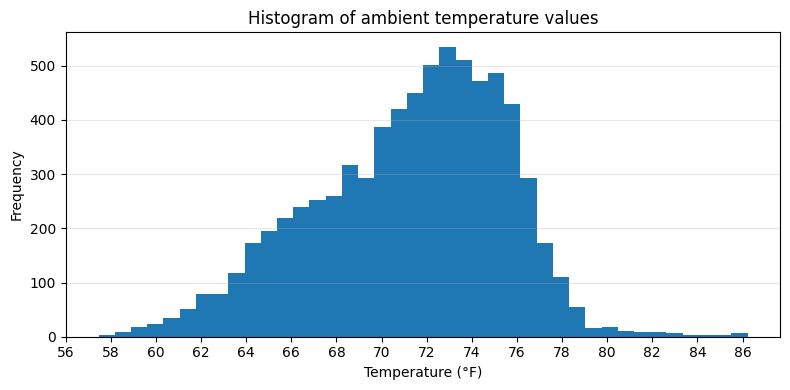

In [41]:
# Step 18 — Temperature value distribution and possible outliers

import matplotlib.pyplot as plt
from IPython.display import display

# Summary statistics with human-friendly labels
temperature_stats = df["value"].describe()

temperature_stats = temperature_stats.rename(index={
    "25%": "Q1 (25%)",
    "50%": "Median (50%)",
    "75%": "Q3 (75%)"
})

temperature_stats_table = temperature_stats.reset_index()
temperature_stats_table.columns = ["statistic", "temperature_value"]

print("Summary statistics for ambient temperature values (°F):")
display(temperature_stats_table)

# Histogram of temperature values
plt.figure(figsize=(8, 4))
plt.hist(df["value"], bins=40)

plt.title("Histogram of ambient temperature values")
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")

# Make x-axis labels more readable
value_min = df["value"].min()
value_max = df["value"].max()

x_axis_start = int(value_min) - 1
x_axis_end = int(value_max) + 2
x_axis_step = 2

plt.xticks(range(x_axis_start, x_axis_end, x_axis_step))

# Add a light horizontal grid to help compare bar heights
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Temperature distribution and possible outliers Interpretation

- Ambient temperature readings are centred around ~71, with most values between roughly 68 and 75.
- The distribution is unimodal and fairly compact, which is consistent with a controlled indoor environment.
- Values above 80 are rare and extend up to about 86, forming the upper tail of the distribution.
- These rare high values align with our interpretation of warm spike anomalies and provide a natural region where some anomalies may live in the value space.


# Visualise Sample

## Visualise Time Series with Anomaly Markers

In [11]:
#plotting figures
import matplotlib.pyplot as plt 

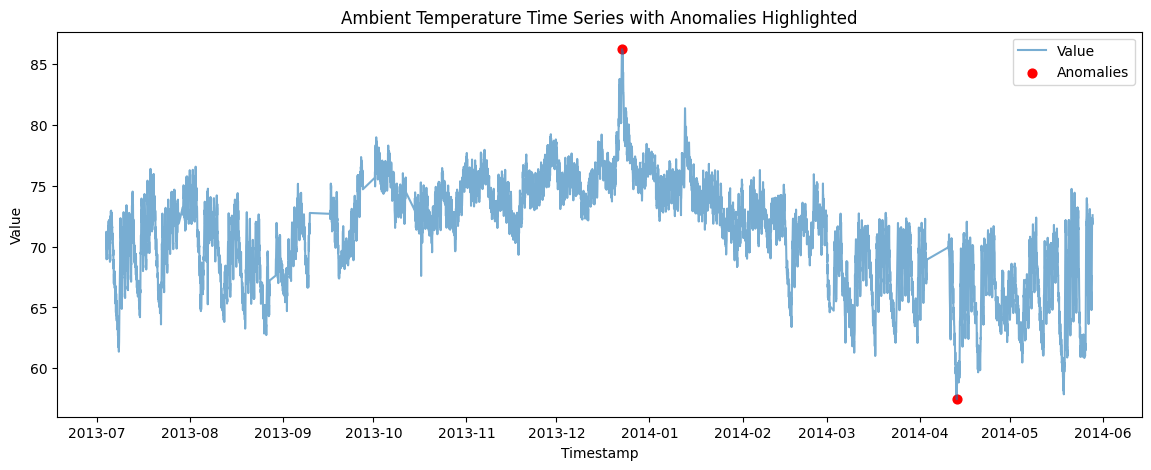

In [12]:
# Make the figure wider so it's easier to read
plt.figure(figsize=(14, 5))

# Plot the main time series
plt.plot(df["timestamp"], df["value"], label="Value", alpha=0.6)

# Select only the anomaly rows (where is_anomaly == 1)
anomaly_points = df[df["is_anomaly"] == 1]

# Plot the anomaly points as red dots on top of the line
plt.scatter(
    anomaly_points["timestamp"],
    anomaly_points["value"],
    label="Anomalies",
    color="red",
    s=40
)

# Add basic labels and legend
plt.title("Ambient Temperature Time Series with Anomalies Highlighted")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()

plt.show()


## Zoom into Each Anomaly Region

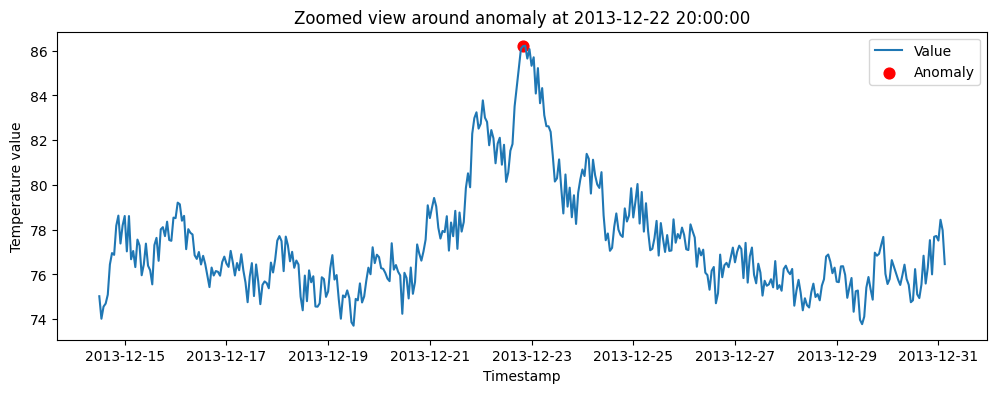

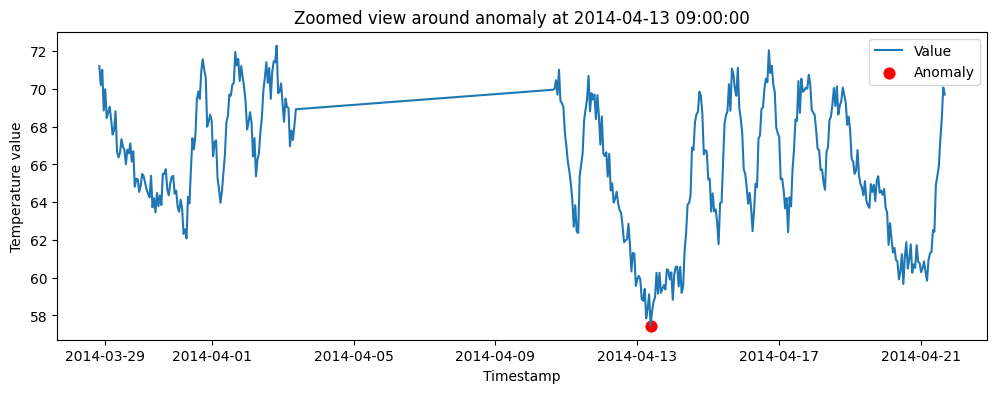

In [13]:
window_size = 200  # number of data points before and after the anomaly

for anomaly_time in label_times_dt:
    # Find the index (row number) where the timestamp equals this anomaly time
    anomaly_index = df.index[df["timestamp"] == anomaly_time][0]
    
    # Define the index range for zooming around the anomaly
    start_index = max(0, anomaly_index - window_size)
    end_index = min(len(df), anomaly_index + window_size)
    
    # Create a new figure
    plt.figure(figsize=(12, 4))
    
    # Plot the zoomed time window
    plt.plot(
        df["timestamp"].iloc[start_index:end_index],
        df["value"].iloc[start_index:end_index],
        label="Value"
    )
    
    # Plot the anomaly point itself
    plt.scatter(
        [anomaly_time],                             # x = the anomaly timestamp
        df.loc[df["timestamp"] == anomaly_time, "value"],  # y = its value
        color="red",
        s=60,                                       # marker size
        label="Anomaly"
    )
    
    plt.title(f"Zoomed view around anomaly at {anomaly_time}")
    plt.xlabel("Timestamp")
    plt.ylabel("Temperature value")
    plt.legend()
    plt.show()


## Moving average of ambient temperature over time

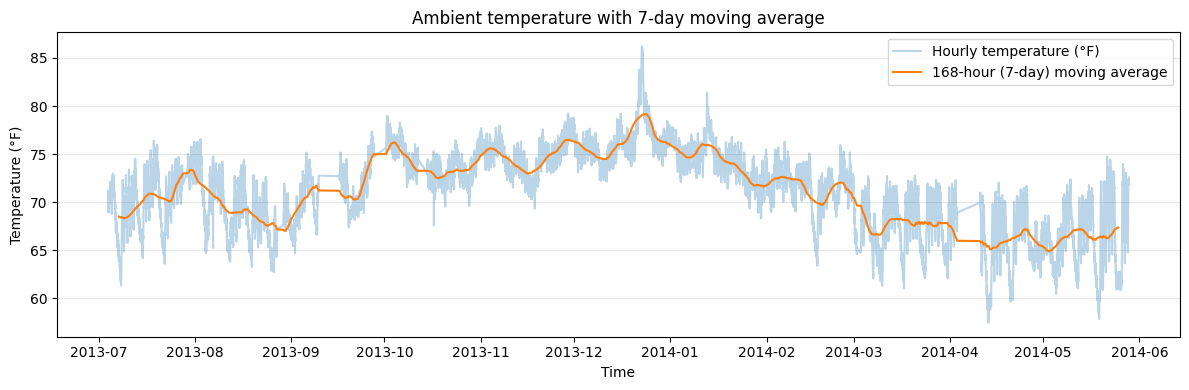

In [43]:
# Ensure data is sorted by time
df = df.sort_values("timestamp").reset_index(drop=True)

# Use a 7-day (7 * 24 hours) moving average to see slow changes
moving_window_hours = 7 * 24

moving_average_temperature = (
    df["value"]
    .rolling(window = moving_window_hours, center=True)
    .mean()
)

plt.figure(figsize=(12, 4))

# Plot the original hourly values in a light line
plt.plot(
    df["timestamp"],
    df["value"],
    alpha=0.3,
    label="Hourly temperature (°F)"
)

# Plot the smoother 7-day moving average
plt.plot(
    df["timestamp"],
    moving_average_temperature,
    label=f"{moving_window_hours}-hour (7-day) moving average",
)

plt.title("Ambient temperature with 7-day moving average")
plt.xlabel("Time")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


7-day moving average Interpretation 

**Interpretation — 7-day moving average**

- The blue line shows the raw hourly temperatures, which move up and down a lot.
- The orange line is the 7-day moving average. For each point in time, it takes the temperatures from roughly the surrounding 7 days and replaces them with a single average value.
- This has two effects:
  - It **smooths out short spikes and dips** (for example, sudden jumps due to doors opening, heaters switching on/off, or sensor noise).
  - It reveals the **slower background pattern**: the temperature gradually rises towards the end of the year and then slowly drops again.
- In other words, the moving average shows the **baseline behaviour** of the system over weeks, while ignoring the fast noise. This baseline is what we think of when we talk about slower changes or “drift” in the operational environment.



## Anomaly summary

In [46]:
# Basic counts
total_points = len(df)
anomaly_count = int(df["is_anomaly"].sum())      # count of rows where is_anomaly == 1
normal_count = total_points - anomaly_count      # everything else is normal

# Percentage of anomalies in the whole series
anomaly_fraction = anomaly_count / total_points * 100

# Small summary table for normal vs anomaly
anomaly_summary_table = pd.DataFrame({
    "class": ["Normal", "Anomaly"],
    "count": [normal_count, anomaly_count],
})

# Add percentage column for each class
anomaly_summary_table["percentage"] = (
    anomaly_summary_table["count"] / total_points * 100
)

print("Overall anomaly summary:")
display(anomaly_summary_table)

# Print simple text summary as well
print(f"\nTotal number of points: {total_points}")
print(f"Number of anomalies: {anomaly_count}")
print(f"Anomalies as % of total: {anomaly_fraction:.4f}%")

# Time coverage of the series
time_start = df["timestamp"].min()
time_end = df["timestamp"].max()

print(f"\nTime span covered by this series:")
print(f"From: {time_start}")
print(f"To:   {time_end}")


Overall anomaly summary:


,class,count,percentage
0,Normal,7265,99.972478
1,Anomaly,2,0.027522



Total number of points: 7267
Number of anomalies: 2
Anomalies as % of total: 0.0275%

Time span covered by this series:
From: 2013-07-04 00:00:00
To:   2014-05-28 15:00:00


Anomaly summary Interpretation

- Only a very small fraction of points are labeled as anomalies compared to normal points. This reflects a highly imbalanced setting, which is typical in real anomaly detection problems.
- The time span printed above shows the operational period covered by this ambient temperature series. This will be useful later when we design experiments that look at performance over different periods (for example, in the context of concept drift).
